In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
dataset = pd.read_csv(r"/home/mj/Documents/notebook/bank-customer-churn-mldl/Churn_Modelling.csv")
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
dataset.drop(columns=["RowNumber", "CustomerId", "Surname"],inplace=True)
dataset.sample(5)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
704,659,Germany,Male,36,2,76190.48,2,1,1,149066.14,0
9208,726,France,Female,44,2,0.00,2,1,1,26733.86,0
3203,719,France,Male,69,3,0.00,2,1,1,58320.06,0
5229,675,France,Male,35,8,0.00,2,1,1,56642.97,0
2439,566,France,Female,42,6,0.00,1,1,0,180702.12,1


In [4]:
dataset['Gender'].replace({"Female":0, "Male":1}, inplace=True)
dataset.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0


In [5]:
dataset.Geography.unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [6]:

dataset.Geography.replace({'France':0, 'Spain':1, 'Germany':2},inplace=True)
dataset.sample(6)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7672,555,0,1,30,1,0.00,2,0,0,88146.86,0
1602,571,0,0,42,4,108825.34,3,1,0,55558.51,1
1351,648,0,0,54,9,120633.42,1,0,0,5924.38,1
5786,588,0,1,40,5,0.00,2,0,0,100727.68,0
2835,653,1,1,35,6,116662.96,2,1,1,23864.21,0
7843,586,2,0,36,5,103700.69,1,1,0,194072.56,1


In [7]:
scale_cols = ["CreditScore", "Age", "Balance", "EstimatedSalary"]

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

dataset[scale_cols] = scaler.fit_transform(dataset[scale_cols])

dataset.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0.538,0,0,0.324324,2,0.000000,1,1,1,0.506735,1
1,0.516,1,0,0.310811,1,0.334031,1,0,1,0.562709,0
2,0.304,0,0,0.324324,8,0.636357,3,1,0,0.569654,1
3,0.698,0,0,0.283784,1,0.000000,2,0,0,0.469120,0
4,1.000,1,0,0.337838,2,0.500246,1,1,1,0.395400,0


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(dataset.iloc[:,:-1],
                                                    dataset.Exited,
                                                    test_size=0.2, random_state=5)
X_test.shape, X_train.shape

((2000, 10), (8000, 10))

In [9]:
from tensorflow import keras
import tensorflow as tf

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(10,)),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=['accuracy']

)

model.fit(X_train, y_train, epochs=500)

2026-03-05 06:10:12.279471: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-05 06:10:12.319495: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-05 06:10:13.200961: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-05 06:10:13.349008: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 606us/step - accuracy: 0.7954 - loss: 0.4906
Epoch 2/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step - accuracy: 0.8061 - loss: 0.4556
Epoch 3/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 561us/step - accuracy: 0.8111 - loss: 0.4419
Epoch 4/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step - accuracy: 0.8123 - loss: 0.4334
Epoch 5/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step - accuracy: 0.8173 - loss: 0.4233
Epoch 6/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 699us/step - accuracy: 0.8195 - loss: 0.4150
Epoch 7/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step - accuracy: 0.8253 - loss: 0.4083
Epoch 8/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step - accuracy: 0.8263 - loss: 0.4018
Epoch 9/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 633us/step - accuracy: 0.8319 - loss: 0.3943
Epoch 10/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step - accuracy: 0.8331 - loss: 0.3900
Epoch 11/500
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 576us/step - accuracy: 0.8396 - loss: 0.3839
Epoch 12/500
250/25

In [10]:
model.evaluate(X_test, y_test)

yp = model.predict(X_test)

model_prd = []
for item in yp:
    if (item < 0.5):
        model_prd.append(0)
    else:
        model_prd.append(1)

model_prd

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 754us/step - accuracy: 0.8400 - loss: 0.4036
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 691us/step


[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,


In [11]:
from xgboost import XGBClassifier

clf = XGBClassifier()

clf.fit(X_train, y_train)
clf.score(X_test, y_test)*100
clf_prd = clf.predict(X_test)
clf_prd

array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [12]:
from sklearn.ensemble import RandomForestClassifier
clf2 = RandomForestClassifier(n_estimators=500,
                              random_state=42,
                              max_depth=5)

clf2.fit(X_train, y_train)

clf2.score(X_train, y_train)*100, clf2.score(X_test, y_test)*100
clf_prd2 = clf.predict(X_test)
clf_prd2

array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

print(f"\t\t\t\tmodel= \n{classification_report(y_test, model_prd)}\n")
print(f"\t\t\t\txgboost= \n{classification_report(y_test, clf_prd)}\n")
print(f"\t\t\t\trandomForest= \n{classification_report(y_test, clf_prd2)}\n")



				model= 
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      1595
           1       0.63      0.52      0.57       405

    accuracy                           0.84      2000
   macro avg       0.76      0.72      0.73      2000
weighted avg       0.83      0.84      0.83      2000


				xgboost= 
              precision    recall  f1-score   support

           0       0.87      0.94      0.91      1595
           1       0.68      0.46      0.54       405

    accuracy                           0.85      2000
   macro avg       0.77      0.70      0.73      2000
weighted avg       0.83      0.85      0.83      2000


				randomForest= 
              precision    recall  f1-score   support

           0       0.87      0.94      0.91      1595
           1       0.68      0.46      0.54       405

    accuracy                           0.85      2000
   macro avg       0.77      0.70      0.73      2000
weighted avg       0.83    

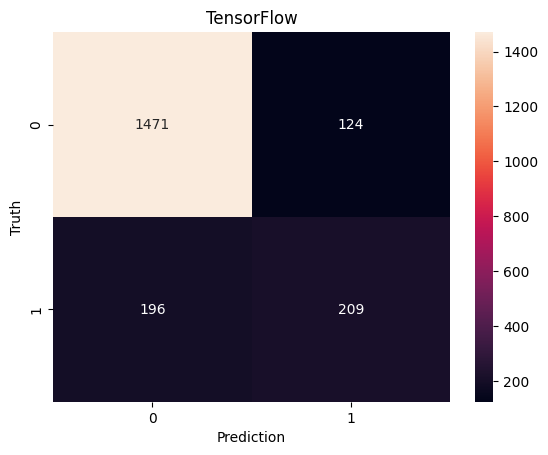

In [14]:
cm = confusion_matrix(y_test, model_prd)

plt.title("TensorFlow")
sns.heatmap(cm, fmt="d", annot=True)
plt.xlabel("Prediction")
plt.ylabel("Truth")
plt.show()

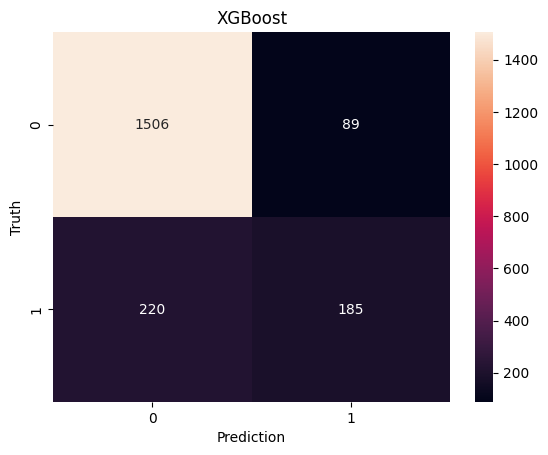

In [15]:
cm2 = confusion_matrix(y_test, clf_prd)

plt.title("XGBoost")
sns.heatmap(cm2, fmt="d", annot=True)
plt.xlabel("Prediction")
plt.ylabel("Truth")
plt.show()

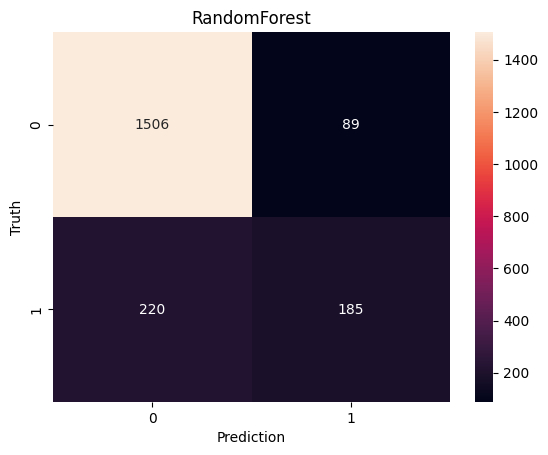

In [16]:
cm3 = confusion_matrix(y_test, clf_prd2)

plt.title("RandomForest")
sns.heatmap(cm3, fmt="d", annot=True)
plt.xlabel("Prediction")
plt.ylabel("Truth")
plt.show()